In [1]:
from tqdm import tqdm
import pickle
import glob
from tqdm import tqdm
import pickle
import glob
from experiments.end_to_end.proof_node import ErrorNode, Status
import math

bestfs_path = '../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/'

bfs_path = '../runs/end_to_end/bfs/2024_04_05/18_45_30/traces/0/'
diversity_p9_t2 = '../runs/minif2f/diversity_search-p0.9-t2/2024_08_02/12_00_25/traces/0/'
diversity_p99_t2 = '../runs/minif2f/diversity_search-p0.99-t2/2024_08_02/23_49_24/traces/0/'
diversity_p99_t1 = '../runs/minif2f/diversity_search-p0.99-t1/2024_08_04/13_12_27/traces/0/'
diversity_p9_t1 = '../runs/minif2f/after_env_filter/2024_08_06/17_28_20/traces/0/'
diveristy_p75_t1 = '../runs/minif2f/after_env_filter/2024_08_01/17_53_29/traces/0/'

def load_traces(path):
    files = glob.glob(path + '*', recursive=True)
    traces = []

    for file in tqdm(files):
        traces.append(pickle.load(open(file, "rb")))

    return traces

In [2]:
diversity_tac_p095_t1 = '../runs/diversity_tac_model_p095_t1/'

In [3]:
# bfs_traces = load_traces(bfs_path)
bestfs_traces = load_traces(bestfs_path)

100%|██████████| 244/244 [00:15<00:00, 15.57it/s]


In [8]:
diversity_p9_t1_traces = load_traces(diversity_p9_t1)
diversity_p9_t2_traces = load_traces(diversity_p9_t2)
diversity_p99_t1_traces = load_traces(diversity_p99_t1)
diversity_p99_t2_traces = load_traces(diversity_p99_t2)

100%|██████████| 244/244 [00:16<00:00, 14.94it/s]


In [4]:

diversity_p75_t1_traces = load_traces(diveristy_p75_t1)

100%|██████████| 244/244 [00:14<00:00, 16.54it/s]


In [9]:
diversity_tac_p095_t1_traces = load_traces(diversity_tac_p095_t1)

100%|██████████| 244/244 [00:04<00:00, 58.69it/s]


In [10]:
best_fs_proved = [a.theorem.full_name for a in bestfs_traces if a.proof]
diversity_p9_t1_proved = [a.theorem.full_name for a in diversity_p9_t1_traces if a.proof]
diversity_p9_t2_proved = [a.theorem.full_name for a in diversity_p9_t2_traces if a.proof]
diversity_p99_t1_proved = [a.theorem.full_name for a in diversity_p99_t1_traces if a.proof]
diversity_p99_t2_proved = [a.theorem.full_name for a in diversity_p99_t2_traces if a.proof]

In [16]:
diversity_p75_t1_proved = [a.theorem.full_name for a in diversity_p75_t1_traces if a.proof]

In [18]:
diversity_p75_t1_proved

['numbertheory_2dvd4expn',
 'mathd_algebra_410',
 'mathd_numbertheory_101',
 'mathd_numbertheory_35',
 'mathd_numbertheory_136',
 'mathd_algebra_35',
 'mathd_numbertheory_84',
 'numbertheory_nckeqnm1ckpnm1ckm1',
 'mathd_algebra_126',
 'mathd_algebra_159',
 'mathd_numbertheory_30',
 'mathd_algebra_214',
 'mathd_algebra_67',
 'mathd_algebra_192',
 'mathd_numbertheory_252',
 'mathd_numbertheory_37',
 'algebra_2rootsintpoly_am10tap11eqasqpam110',
 'mathd_algebra_182',
 'mathd_numbertheory_188',
 'mathd_algebra_455',
 'mathd_numbertheory_466',
 'amc12a_2017_p2',
 'mathd_numbertheory_149',
 'mathd_algebra_96',
 'algebra_2complexrootspoly_xsqp49eqxp7itxpn7i',
 'mathd_algebra_15',
 'mathd_numbertheory_132',
 'mathd_numbertheory_370',
 'mathd_numbertheory_211',
 'mathd_algebra_51',
 'mathd_algebra_616',
 'mathd_algebra_37',
 'mathd_algebra_251',
 'mathd_numbertheory_301',
 'algebra_manipexpr_2erprsqpesqeqnrpnesq',
 'mathd_algebra_109',
 'mathd_algebra_123',
 'mathd_algebra_10',
 'mathd_numberth

In [25]:
diversity_tac_p095_t1_proved = [a.theorem.full_name for a in diversity_tac_p095_t1_traces if a.proof]

In [26]:
len(best_fs_proved), len(diversity_p9_t1_proved),  len(diversity_p9_t2_proved), len(diversity_p99_t1_proved), len(diversity_p99_t2_proved), len(diversity_p75_t1_proved), len(diversity_tac_p095_t1_proved)

(68, 67, 67, 68, 68, 66, 66)

In [37]:
# get the union ov proven diversity theorems
diversity_proved = set( diversity_tac_p095_t1_proved)# + diversity_p9_t2_proved )#+ diversity_p99_t1_proved) #+ diversity_p99_t2_proved)
len(diversity_proved)

66

In [38]:
# get the intersection of proved theorems, and number unique to each set

best_fs_proved_set = set(best_fs_proved)

intersection = diversity_proved.intersection(best_fs_proved_set)

diversity_unique = diversity_proved.difference(best_fs_proved_set)

best_fs_unique = best_fs_proved_set.difference(diversity_proved)

len(intersection), len(diversity_unique), len(best_fs_unique)

(64, 2, 4)

In [76]:
tac_times = [a.time for trace in bestfs_traces for x in trace.data['search_trace'] for a in x]


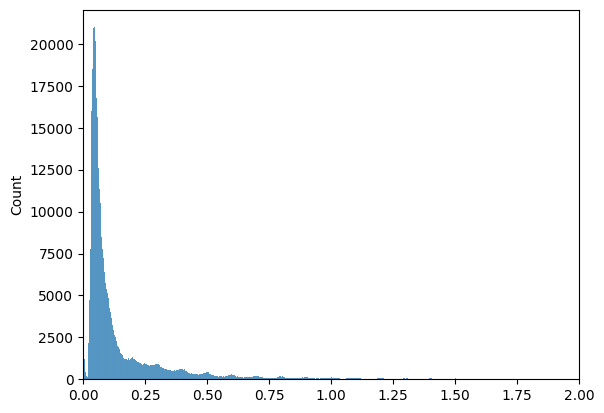

In [74]:
# plot histogram of times with seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(tac_times,)
plt.xlim(0, 2)
plt.show()



In [78]:
[(a.tactic, a.time) for x in bestfs_traces[0].data['search_trace'] for a in x]


[('norm_num', 1.938549013924785),
 ('exact <a>dvd_pow_self</a> n h₀', 0.9034348400309682),
 ('exact <a>dvd_pow_self</a> _ h₀', 0.6928272529039532),
 ('apply <a>dvd_pow_self</a>', 0.30623572296462953),
 ('cases n', 0.49262847006320953),
 ('simp', 1.6020621240604669),
 ('apply <a>pow_dvd_pow</a>', 0.6018329130019993),
 ('apply <a>nat.dvd_prime_pow</a>', 0.3917936800280586),
 ('rcases <a>eq_or_ne</a> n 0 with rfl | hn', 0.41072676598560065),
 ('apply <a>dvd_pow</a>', 0.2982223950093612),
 ('apply <a>nat.dvd_pow_self</a>', 0.289895687950775),
 ('simp [h₀]', 1.8113201700616628),
 ('exact <a>dvd_pow_self</a> 2 h₀', 1.2962895170785487),
 ('use n', 1.0155127319740131),
 ('by_cases h₁ : 0 < n', 0.48699179699178785),
 ('rw ←<a>even_iff_two_dvd</a>', 0.816542423912324),
 ('exact <a>dvd_pow_self</a> 1 h₀', 0.5810651809442788),
 ('apply <a>dvd_pow_self</a> _ h₀', 0.5912671439582482),
 ('by_cases h₁ : n = 0', 0.6123782630311325),
 ('exact <a>dvd_pow_self</a> 4 h₀', 0.5983860079431906),
 ('apply <a>n

In [88]:
[(a.dst[0].inner.message.split(' tactic_state')[0]) for x in bestfs_traces[1].data['search_trace'] for a in x if isinstance(a.dst[0], ErrorNode)]


['gen_tac_and_capture_res_failed: pos=(some ⟨1, 2⟩) msg="simplify tactic failed to simplify"',
 'gen_tac_and_capture_res_failed: pos=(some ⟨1, 2⟩) msg="simplify tactic failed to simplify"',
 'gen_tac_and_capture_res_failed: pos=none msg="try_for_time tactic failed, timeout"',
 'gen_tac_and_capture_res_failed: pos=(some ⟨1, 2⟩) msg="simplify tactic failed to simplify"',
 'gen_tac_and_capture_res_failed: pos=(some ⟨1, 2⟩) msg="failed"',
 'gen_tac_and_capture_res_failed: pos=(some ⟨1, 2⟩) msg="unknown identifier \'real.logb_pow\'"',
 'gen_tac_and_capture_res_failed: pos=(some ⟨1, 2⟩) msg="exact tactic failed, type mismatch, given expression has type\n  true\nbut is expected to have type\n  as_true (real.logb (5 ^ 2) (5 ^ 4) = 2)\nstate:\n⊢ as_true (real.logb (5 ^ 2) (5 ^ 4) = 2)"',
 'gen_tac_and_capture_res_failed: pos=(some ⟨1, 2⟩) msg="exact tactic failed, type mismatch, given expression has type\n  true\nbut is expected to have type\n  as_true (real.logb (5 ^ 2) (5 ^ 4) = 2)\nstate:\n⊢

In [ ]:
# train data path
train_path = 'runs/train_traces/0/'

In [ ]:
train_files = glob.glob(train_path + '*', recursive=True)

In [ ]:
from experiments.end_to_end.proof_node import Status

In [ ]:
# takeaway: fails distributed zipfian, with a few proofs having most fails
# fails with no out_edges are usually root nodes which have errored out
# fails with out_edges are usually nodes which haven't been fully visited, implying an error in one of the expansions

In [ ]:
weird_fails = []
fail_dist = []
true_fails = 0
no_edges = []
for file in tqdm(train_files):
    trace = pickle.load(open(file, 'rb'))

    fail_nodes = [node for node in trace.nodes.values() if node.status == Status.FAILED]
    for node in fail_nodes:
        if node.out_edges:
            if all([any([c.status == Status.FAILED for c in child.dst]) for child in
                    node.out_edges]) and node.visit_count >= node.max_expansions:
                true_fails += 1
            else:
                weird_fails.append(node)
        else:
            no_edges.append(node)

    fail_dist.append(len(fail_nodes))


In [ ]:
len(weird_fails), true_fails, len(no_edges)

In [ ]:
[a.visit_count for a in weird_fails]

In [ ]:
[(type(d.dst[0]), len(d.dst)) for d in weird_fails[0].out_edges]


In [ ]:
weird_fails[0].in_edges

In [ ]:
weird_fails[0]

In [ ]:
# plot histogram of fail_dist, excluding those with 0 value

import matplotlib.pyplot as plt

plt.hist(fail_dist, bins=range(1, max(fail_dist) + 1))
plt.show()


In [ ]:
[type(d.dst[0]) for d in [node for node in trace.nodes.values() if node.status == Status.FAILED][1].out_edges]
# [d.dst[0] for d in [node for node in trace.nodes.values() if node.status == Status.FAILED][0].out_edges]


In [ ]:
# look at distribution of visits for proven nodes

proven_nodes = []
other_nodes = []

visits = {}

for trace in tqdm(bestfs_traces):
    if isinstance(trace.tree, ErrorNode) or not trace.tree.out_edges:
        continue

    nodes = trace.nodes
    nodes[trace.tree.goal] = trace.tree

    visits = {node: nodes[node].visit_count for node in nodes.keys()}

    for goal, node in nodes.items():
        for a in node.ancestors:
            visits[a] += node.visit_count

    for node in trace.nodes.values():
        if node.status == Status.PROVED:
            proven_nodes.append((node, visits[node.goal]))
        else:
            other_nodes.append((node, visits[node.goal]))


In [ ]:
len(proven_nodes)

In [ ]:
len([node for node in other_nodes if node[0].status == Status.FAILED])

In [ ]:
# plot normalised distribution of visits for proven nodes

import matplotlib.pyplot as plt

plt.hist([d[1] for d in proven_nodes], bins=range(0, 4000, 64))


In [ ]:
# print the number of proven nodes with visit counts over 64, 128, 256, 512, 1024, 2048, 4096, 8192

for i in range(8):
    num_over = len([d[0] for d in proven_nodes if d[1] > 64 * 2 ** i]) / len(proven_nodes)
    print(f'Num over {64 * 2 ** i}: {num_over}')

In [ ]:

for i in range(8):
    num_over = len([d[0] for d in other_nodes if d[1] >= 64 * 2 ** i]) / len(other_nodes)
    print(f'Num over {64 * 2 ** i}: {num_over}')


In [ ]:
htps_path = 'runs/end_to_end/htps_no_critic/2024_04_21/16_34_02/traces/0/'

htps_files = glob.glob(htps_path + '*', recursive=True)

In [ ]:
errors = 0
for file in tqdm(htps_files):
    trace = pickle.load(open(file, 'rb'))
    if trace.tree.status == Status.FAILED:
        errors += 1


In [ ]:
errors

In [ ]:
trace = pickle.load(open(htps_files[13], 'rb'))

print(len(trace.data['search_trace']))
print(trace.tree.status)

edge_data, tree, leaves = trace.data['search_trace'][-1]

edge_data